Integrantes: Alejandra HIdalgo y Antonia Luengo


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = "/content/drive/MyDrive/IA/lab3/20240628_Titulados_Ed_Superior_2023_WEB.csv"
ruta2= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2022_WEB.csv"
ruta3= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2021_WEB.csv"
ruta4= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2020_WEB.csv"
ruta5= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2019_WEB.csv"
ruta6= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2018_WEB.csv"
ruta7= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2017_WEB.csv"
ruta8= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2016_WEB.csv"
ruta9= "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2015_WEB.csv"
Titulados = pd.read_csv(ruta, delimiter=';')
Eg2015 = pd.read_csv(ruta9, encoding='latin-1', delimiter=';')
Eg2016 = pd.read_csv(ruta8, encoding='latin-1', delimiter=';')
Eg2017 = pd.read_csv(ruta7, encoding='latin-1', delimiter=';')
Eg2018 = pd.read_csv(ruta6, encoding='latin-1', delimiter=';')
Eg2019 = pd.read_csv(ruta5, encoding='latin-1', delimiter=';')
Eg2020 = pd.read_csv(ruta4, encoding='latin-1', delimiter=';')
Eg2021 = pd.read_csv(ruta3, encoding='latin-1', delimiter=';')
Eg2022 = pd.read_csv(ruta2, encoding='latin-1', delimiter=';')

# EDA

## Egresados

###Unir todos los csv de egresados en uno solo

In [ ]:
lista = [Eg2015, Eg2016, Eg2017, Eg2018, Eg2019, Eg2020, Eg2021, Eg2022]

egresados = pd.concat(lista, ignore_index=True)

###limpiar columnas irrelevantes

In [ ]:
eliminar = ['RBD', 'DGV_RBD', 'COD_DEPROV_RBD', 'NOM_DEPROV_RBD', 'ORIGEN']

egresados = egresados.drop(columns=eliminar)

### Ver de que tipo de dato es cada columna

In [ ]:
egresados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7529401 entries, 0 to 7529400
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   AGNO            int64  
 1   COD_REG_RBD     float64
 2   NOM_REG_RBD_A   object 
 3   COD_PRO_RBD     float64
 4   COD_COM_RBD     float64
 5   NOM_COM_RBD     object 
 6   COD_ENSE        int64  
 7   COD_GRADO       int64  
 8   MRUN            int64  
 9   PROM_NOTAS_ALU  object 
 10  ENSE_COMPLETA   int64  
 11  MARCA_EGRESO    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 689.3+ MB


### Calculamos la moda para ver los datos que mas se repiten

In [ ]:
egresados.mode().iloc[0]

,0
AGNO,2022.0
COD_REG_RBD,13.0
NOM_REG_RBD_A,RM
COD_PRO_RBD,131.0
COD_COM_RBD,13101.0
NOM_COM_RBD,SANTIAGO
COD_ENSE,310.0
COD_GRADO,2.0
MRUN,20
PROM_NOTAS_ALU,"5,5"


### Convertir promedio notas de string a float

In [ ]:
egresados['PROM_NOTAS_ALU'] = egresados['PROM_NOTAS_ALU'].str.replace(',', '.').astype(float)

### Analizar la distribución de notas

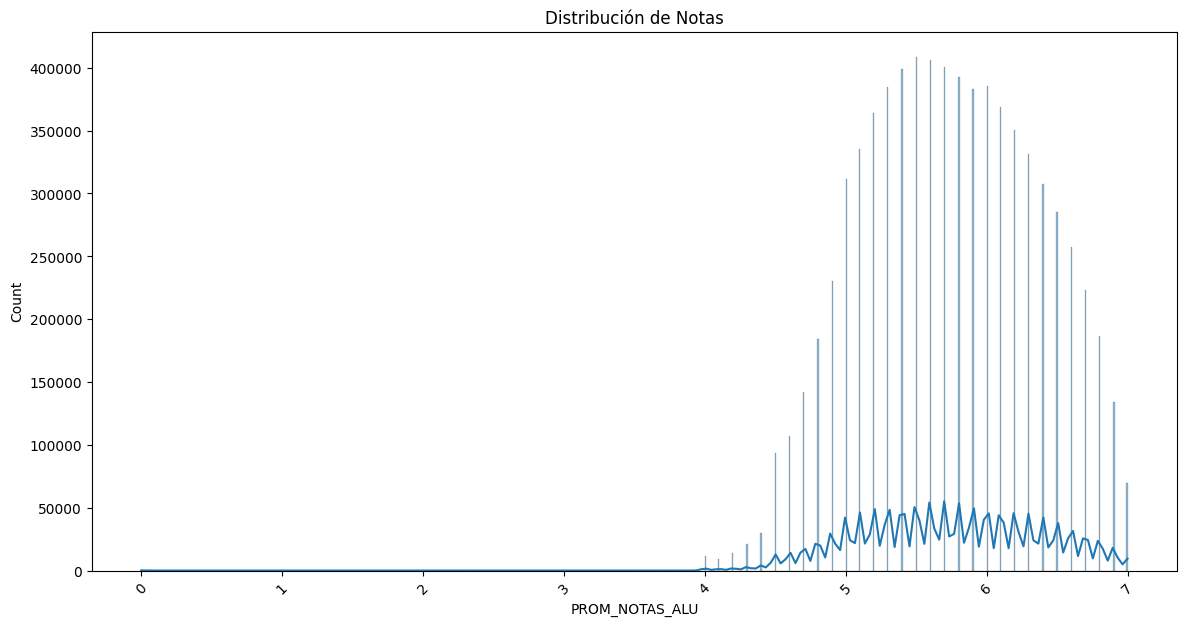

In [ ]:
plt.figure(figsize=(14, 7))
sns.histplot(egresados['PROM_NOTAS_ALU'], kde=True)
plt.title('Distribución de Notas')
plt.xticks(rotation=45)
plt.show()


El gráfico muestra la distribución de un conjunto de promedios de notas (indicadas como "PROM_NOTAS_ALU") de estudiantes. La mayoría de los promedios se concentran entre 4 y 6, con un pico cercano a 5, indicando que esta es la calificación más frecuente. La distribución

### Relacion entre variables numericas

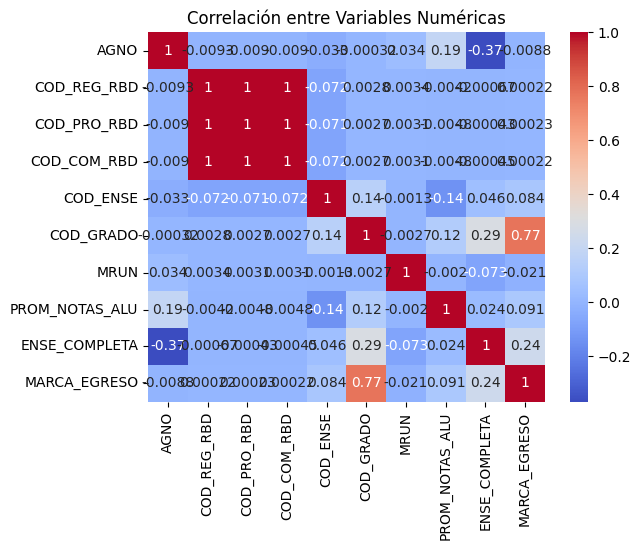

In [ ]:
egresados_numericos = egresados.select_dtypes(include=['float64', 'int64'])

sns.heatmap(egresados_numericos.corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre Variables Numéricas')
plt.show()

El gráfico es un mapa de calor que muestra la matriz de correlación entre variables numéricas. Los valores de correlación están representados con un gradiente de color, donde el rojo indica correlaciones positivas fuertes (cercanas a 1) y el azul correlaciones negativas fuertes (cercanas a -1). Por ejemplo, "COD_GRADO" tiene una fuerte correlación positiva con "MARCA_EGRESO" (0.77), mientras que "ENSE_COMPLETA" muestra una correlación negativa moderada con "AGNO" (-0.37). Esto sugiere relaciones importantes entre ciertas variables, útiles para análisis posteriores.


### relacion entre regiones y promedio de notas

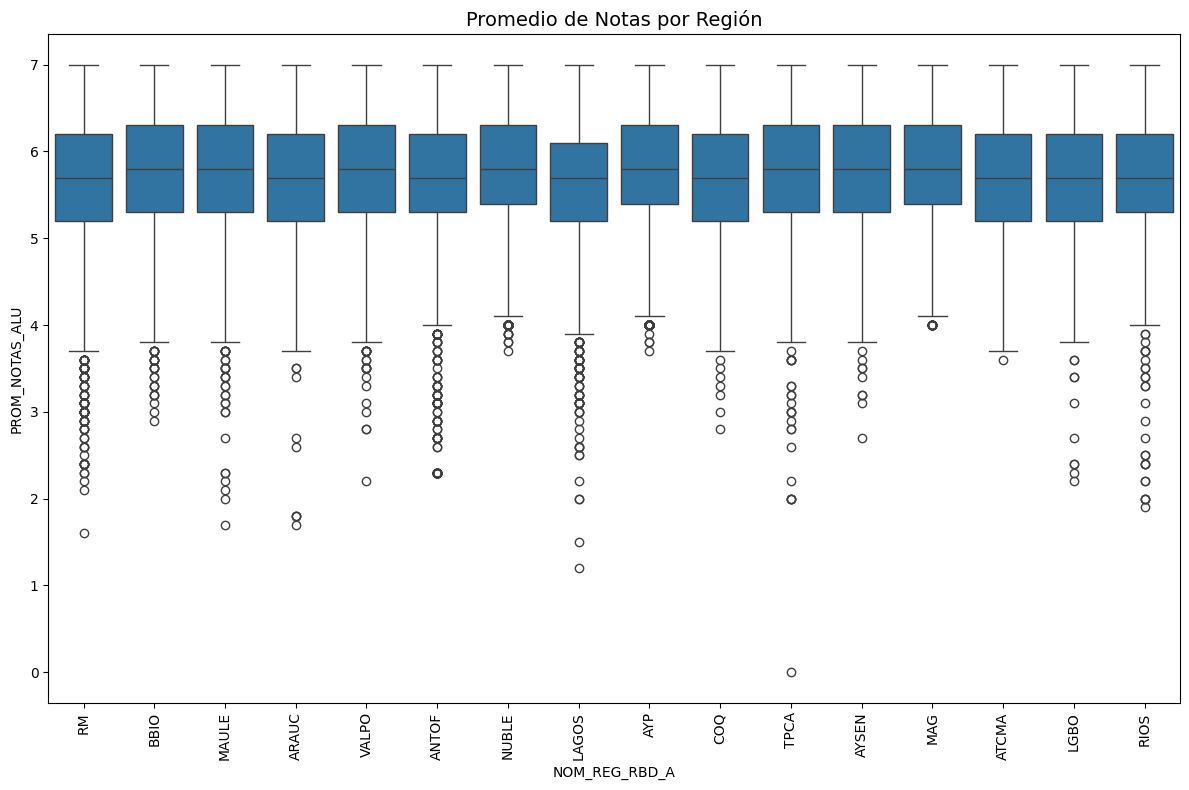

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='NOM_REG_RBD_A', y='PROM_NOTAS_ALU', data=egresados)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.title('Promedio de Notas por Región', fontsize=14)
plt.tight_layout()
plt.show()

El gráfico de cajas muestra la distribución del promedio de notas ("PROM_NOTAS_ALU") por región ("NOM_REG_RBD_A"). Las cajas representan el rango intercuartílico (del primer al tercer cuartil), y las líneas dentro de ellas indican la mediana. Los bigotes muestran el rango de valores no considerados atípicos, mientras que los puntos fuera de los bigotes representan valores atípicos. En general, la mediana del promedio de notas es similar entre las regiones, situándose alrededor de 6, aunque algunas regiones presentan mayor dispersión o más valores atípicos hacia los extremos inferiores (menores a 4).

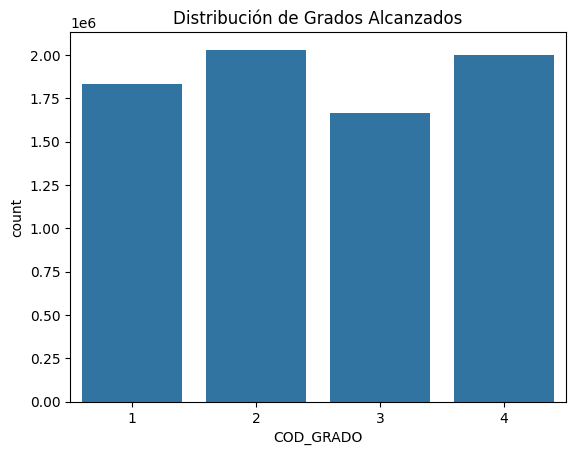

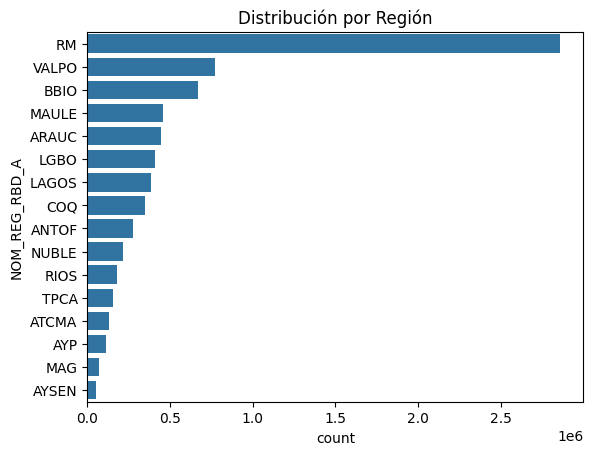

In [ ]:
sns.countplot(x='COD_GRADO', data=egresados)
plt.title('Distribución de Grados Alcanzados')
plt.show()

sns.countplot(y='NOM_REG_RBD_A', data=egresados, order=egresados['NOM_REG_RBD_A'].value_counts().index)
plt.title('Distribución por Región')
plt.show()

El primer gráfico muestra la cantidad de individuos agrupados por el código de grado alcanzado (COD_GRADO). Se observa una distribución relativamente equilibrada entre las categorías, siendo la segunda categoría (COD_GRADO = 2) la que tiene la mayor cantidad de observaciones, seguida de la cuarta y primera categoría. Esto sugiere que los grados alcanzados tienen una representación casi uniforme con ligeras diferencias.

En el segundo gráfico se analiza la distribución de la población según las regiones (NOM_REG_RBD_A). La Región Metropolitana (RM) tiene claramente la mayor concentración de individuos, superando ampliamente a las demás regiones. Le siguen Valparaíso (VALPO) y Biobío (BBIO). Las regiones menos representadas son Aysén, Magallanes (MAG) y Arica y Parinacota (AYP), mostrando una concentración significativa en áreas urbanas.

### Ver si hay nulos

In [ ]:
egresados.isnull().sum()

,0
AGNO,0
COD_REG_RBD,1238
NOM_REG_RBD_A,1238
COD_PRO_RBD,1238
COD_COM_RBD,1238
NOM_COM_RBD,1238
COD_ENSE,0
COD_GRADO,0
MRUN,0
PROM_NOTAS_ALU,0


rellenamos los nulos categoricos con la palabra DESCONOCIDO

In [ ]:
egresados['NOM_COM_RBD'] = egresados['NOM_COM_RBD'].fillna('DESCONOCIDO')

In [ ]:
egresados['NOM_REG_RBD_A'] = egresados['NOM_REG_RBD_A'].fillna('DESCONOCIDO')

rellenamos nulos numericos con 0

In [ ]:
egresados['COD_REG_RBD'] = egresados['COD_REG_RBD'].fillna(0)

In [ ]:
egresados['COD_PRO_RBD'] = egresados['COD_PRO_RBD'].fillna(0)

In [ ]:
egresados['COD_COM_RBD'] = egresados['COD_COM_RBD'].fillna(0)

revisamos nulos nuevamente

In [ ]:
egresados.isnull().sum()

,0
AGNO,0
COD_REG_RBD,0
NOM_REG_RBD_A,0
COD_PRO_RBD,0
COD_COM_RBD,0
NOM_COM_RBD,0
COD_ENSE,0
COD_GRADO,0
MRUN,0
PROM_NOTAS_ALU,0


### codificar columnas categoricas, para que queden en formato numerico antes de entrenar el modelo

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()
egresados['NOM_REG_RBD_A'] = encoder.fit_transform(egresados['NOM_REG_RBD_A'])
egresados['NOM_COM_RBD'] = encoder.fit_transform(egresados['NOM_COM_RBD'])

### escalar variables numericas

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
egresados['PROM_NOTAS_ALU'] = scaler.fit_transform(egresados[['PROM_NOTAS_ALU']])

##Titulados

### eliminar columnas que no sirven

In [ ]:
eliminar2 = ['codigo_unico', 'fec_nac_alu', 'nomb_titulo_obtenido', 'fecha_obtencion_titulo', 'tipo_inst_1', 'tipo_inst_2', 'tipo_inst_3', 'cod_inst', 'nomb_inst', 'cod_sede', 'nomb_sede', 'cod_carrera', 'nomb_carrera',
              'region_sede', 'provincia_sede', 'comuna_sede', 'version', 'area_cineunesco',
              'area_cine_f_97', 'subarea_cine_f_97', 'area_cine_f_13', 'subarea_cine_f_13']

Titulados.drop(columns=eliminar2)

,cat_periodo,mrun,gen_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,anio_ing_carr_act,sem_ing_carr_act,nomb_grado_obtenido,nivel_global,nivel_carrera_1,nivel_carrera_2,dur_estudio_carr,dur_proceso_tit,dur_total_carr,jornada,modalidad,tipo_plan_carr,area_carrera_generica_n
0,2023,99.0,1,20 a 24 Años,2021,1,2021,1,NaN,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,5,1,5,Diurno,Presencial,Plan Regular,Técnico en Geología
1,2023,137.0,1,20 a 24 Años,2021,1,2021,1,NaN,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,4,0,4,Vespertino,Presencial,Plan Regular,Técnico en Mecánica Automotriz
2,2023,346.0,2,20 a 24 Años,2019,1,2022,1,NaN,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,4,0,4,Diurno,Presencial,Plan Regular,Técnico en Contabilidad General
3,2023,385.0,2,20 a 24 Años,2018,1,2018,1,LICENCIADO EN OCUPACION HUMANA,Pregrado,Profesional Con Licenciatura,Carreras Profesionales,10,0,10,Diurno,Presencial,Plan Regular,Terapia Ocupacional
4,2023,393.0,1,25 a 29 Años,1900,0,2020,1,NaN,Pregrado,Profesional Sin Licenciatura,Carreras Profesionales,4,0,4,Vespertino,Presencial,Plan Regular de Continuidad,Ingeniería Agrícola
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297169,2023,NaN,2,40 y más años,2022,1,2022,1,MAGISTER EN ADMINISTRACION DE EMPRESAS,Postgrado,Magister,Magister,4,0,4,Vespertino,Presencial,Plan Regular,Magister en Administración y Comercio
297170,2023,NaN,2,40 y más años,2022,1,2022,1,NO OTORGA GRADO,Postítulo,Diplomado (superior a un semestre),Postítulo,2,0,2,Vespertino,Presencial,Plan Regular,Postítulo en Derecho
297171,2023,NaN,2,20 a 24 Años,2022,2,2022,2,NaN,Postítulo,Diplomado (superior a un semestre),Postítulo,2,0,2,A Distancia,No Presencial,Plan Regular,Postítulo en Administración y Comercio
297172,2023,NaN,1,30 a 34 Años,2021,1,2021,1,MAGISTER EN FINANZAS,Postgrado,Magister,Magister,4,0,4,Diurno,Presencial,Plan Regular,Magister en Administración y Comercio


### Revisar el tipo de dato de cada columna

In [ ]:
Titulados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297174 entries, 0 to 297173
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat_periodo              297174 non-null  int64  
 1   mrun                     296708 non-null  float64
 2   gen_alu                  297174 non-null  int64  
 3   rango_edad               297174 non-null  object 
 4   anio_ing_carr_ori        297174 non-null  int64  
 5   sem_ing_carr_ori         297174 non-null  int64  
 6   anio_ing_carr_act        297174 non-null  int64  
 7   sem_ing_carr_act         297174 non-null  int64  
 8   nomb_grado_obtenido      128331 non-null  object 
 9   nivel_global             297174 non-null  object 
 10  nivel_carrera_1          297174 non-null  object 
 11  nivel_carrera_2          297174 non-null  object 
 12  dur_estudio_carr         297174 non-null  int64  
 13  dur_proceso_tit          297174 non-null  int64  
 14  dur_

In [ ]:
Titulados.isnull().sum()

,0
cat_periodo,0
mrun,466
gen_alu,0
rango_edad,0
anio_ing_carr_ori,0
sem_ing_carr_ori,0
anio_ing_carr_act,0
sem_ing_carr_act,0
nomb_grado_obtenido,168843
nivel_global,0


gestion nulos

In [ ]:
Titulados.dropna(subset=['mrun'])

,cat_periodo,codigo_unico,mrun,gen_alu,fec_nac_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,anio_ing_carr_act,sem_ing_carr_act,...,jornada,modalidad,version,tipo_plan_carr,area_cineunesco,area_cine_f_97,subarea_cine_f_97,area_cine_f_13,subarea_cine_f_13,area_carrera_generica_n
0,2023,I111S12C420J1V1,99.0,1,200301,20 a 24 Años,2021,1,2021,1,...,Diurno,Presencial,1.0,Plan Regular,Ciencias Básicas,Ciencias,Ciencias Físicas,"Ciencias naturales, matemáticas y estadística",Ciencias Físicas,Técnico en Geología
1,2023,I430S10C326J2V1,137.0,1,200104,20 a 24 Años,2021,1,2021,1,...,Vespertino,Presencial,1.0,Plan Regular,Tecnología,"Ingeniería, Industria y Construcción",Ingeniería y Profesiones Afines,"Ingeniería, Industria y Construcción",Ingeniería y Profesiones Afines,Técnico en Mecánica Automotriz
2,2023,I430S22C45J1V1,346.0,2,200005,20 a 24 Años,2019,1,2022,1,...,Diurno,Presencial,1.0,Plan Regular,Administración y Comercio,"Ciencias Sociales, Enseñanza Comercial y Derecho",Enseñanza Comercial y Administración,Administración de Empresas y Derecho,Educación Comercial y Administración,Técnico en Contabilidad General
3,2023,I13S17C44J1V1,385.0,2,200006,20 a 24 Años,2018,1,2018,1,...,Diurno,Presencial,1.0,Plan Regular,Salud,Salud y Servicios Sociales,Medicina,Salud y Bienestar,Salud,Terapia Ocupacional
4,2023,I116S19C207J2V1,393.0,1,199409,25 a 29 Años,1900,0,2020,1,...,Vespertino,Presencial,1.0,Plan Regular de Continuidad,Agropecuaria,Agricultura,"Agricultura, Silvicultura y Pesca","Agricultura, Silvicultura, Pesca y Veterinaria",Agricultura,Ingeniería Agrícola
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296703,2023,I23S3C272J1V1,27832045.0,2,198305,40 y más años,2022,1,2022,1,...,Diurno,Presencial,1.0,Plan Regular,Ciencias Sociales,"Ciencias Sociales, Enseñanza Comercial y Derecho",Ciencias Sociales y del Comportamiento,"Ciencias Sociales, Periodismo e Información",Ciencias Sociales y del Comportamiento,Postítulo en Ciencias Sociales
296704,2023,I86S1C726J4V1,27832052.0,1,196812,40 y más años,2022,2,2022,2,...,A Distancia,No Presencial,1.0,Plan Regular,Tecnología,Ciencias,Matemáticas y Estadísticas,"Ciencias naturales, matemáticas y estadística",Matemáticas y Estadísticas,Postítulo en Tecnología
296705,2023,I23S3C457J4V1,27832064.0,1,197104,40 y más años,2021,2,2021,2,...,A Distancia,No Presencial,1.0,Plan Regular,Tecnología,Ciencias,Informática,Tecnología de la Información y la Comunicación...,Tecnología de la Información y la Comunicación...,Postítulo en Tecnología
296706,2023,I78S1C15J1V1,27832067.0,2,199609,25 a 29 Años,1900,0,2022,1,...,Diurno,Presencial,1.0,Plan Regular,Salud,Salud y Servicios Sociales,Medicina,Salud y Bienestar,Salud,Kinesiología


### Distribucion variables categoricas

###Distribución de rango de edad

<ipython-input-27-8b27748b6c6f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Titulados, x='rango_edad', order=Titulados['rango_edad'].value_counts().index, palette='viridis')


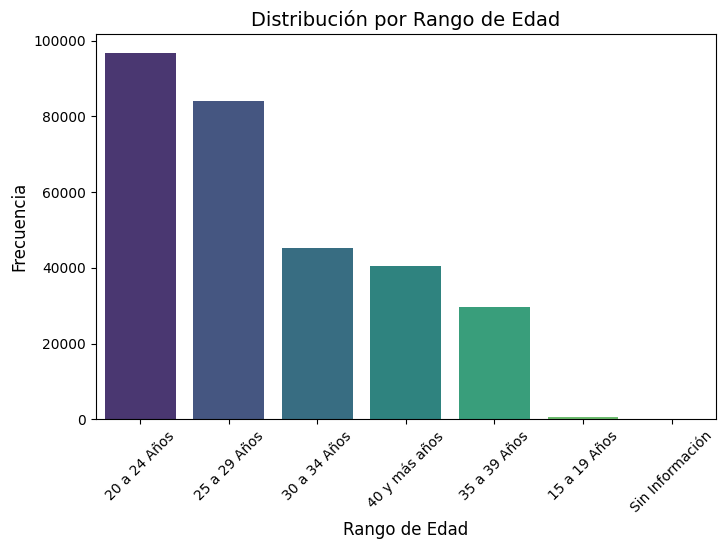

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=Titulados, x='rango_edad', order=Titulados['rango_edad'].value_counts().index, palette='viridis')
plt.title('Distribución por Rango de Edad', fontsize=14)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Aquí se representa la frecuencia de individuos en distintos rangos de edad. El rango más común es el de 20 a 24 años, seguido del de 25 a 29 años, lo que indica una mayor participación de jóvenes adultos. La frecuencia disminuye gradualmente en los rangos de edad mayores, con una representación mínima en el rango de 15 a 19 años y un grupo etiquetado como "Sin Información". Esto sugiere que el grupo objetivo principal pertenece a jóvenes adultos.

### Distribución de nivel global

<ipython-input-31-34c8fdd0df23>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Titulados, x='nivel_global', palette='pastel')


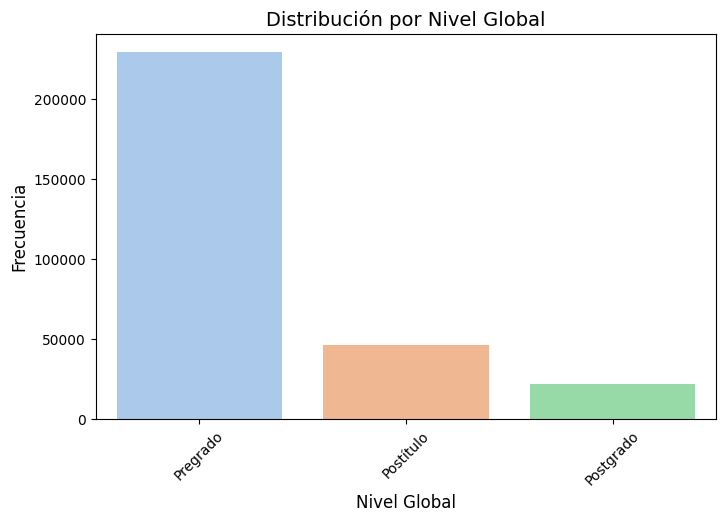

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=Titulados, x='nivel_global', palette='pastel')
plt.title('Distribución por Nivel Global', fontsize=14)
plt.xlabel('Nivel Global', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Podemos ver que las carreras que mas frecuencia tienen son de pregrado, seguido de postítulo y por ultimo postrgrado

### Análisis de área de carrera

<ipython-input-42-745456a74d6a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.values, y=area_counts.index, palette='cubehelix')


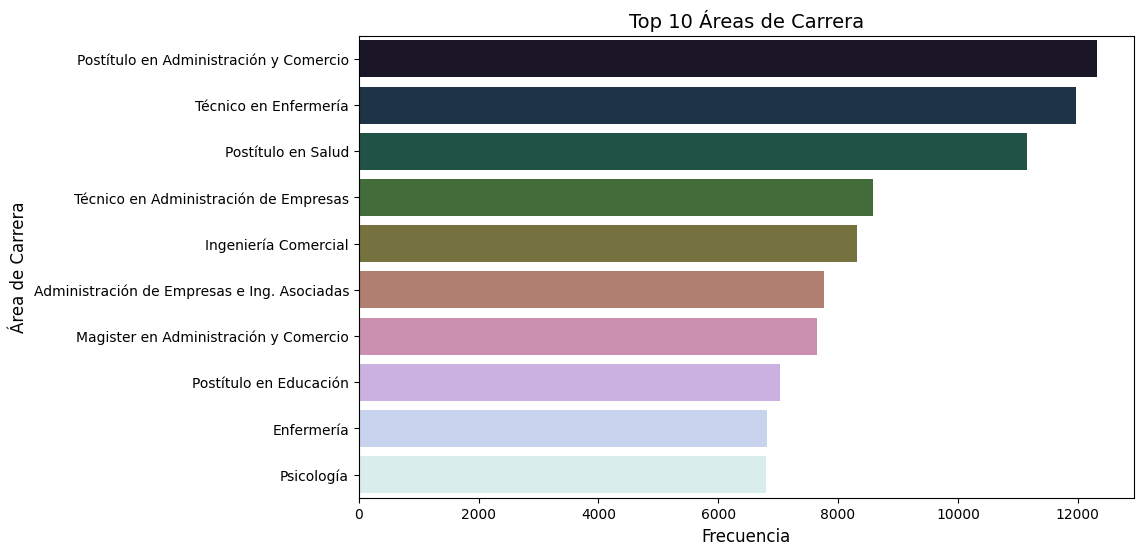

In [ ]:
plt.figure(figsize=(10, 6))
area_counts = Titulados['area_carrera_generica_n'].value_counts().head(10)
sns.barplot(x=area_counts.values, y=area_counts.index, palette='cubehelix')
plt.title('Top 10 Áreas de Carrera', fontsize=14)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Área de Carrera', fontsize=12)
plt.show()

Se ven las areas de carrera mas populares

### Duración total de la carrera (boxplot)

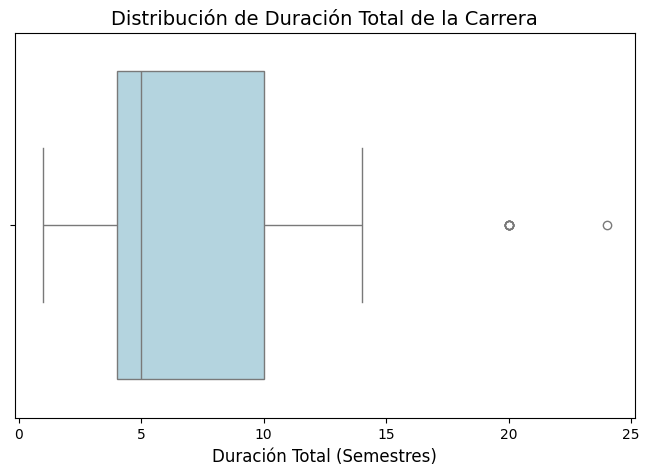

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=Titulados, x='dur_total_carr', color='lightblue')
plt.title('Distribución de Duración Total de la Carrera', fontsize=14)
plt.xlabel('Duración Total (Semestres)', fontsize=12)
plt.show()

#pipeline


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from google.colab import drive

drive.mount('/content/drive')

#reducir el uso de memoria
def reduce_memory_usage(df):
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type != object:
            if str(col_type).startswith('int'):
                df[col] = pd.to_numeric(df[col], downcast='integer')
            elif str(col_type).startswith('float'):
                df[col] = pd.to_numeric(df[col], downcast='float')
    return df

#cargar archivos CSV en fragmentos
def cargar_datos_csv(ruta, chunksize=100000):
    chunks = []
    for chunk in pd.read_csv(ruta, delimiter=';', encoding='latin-1', chunksize=chunksize):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

#rutas
ruta_titulados = "/content/drive/MyDrive/IA/lab3/20240628_Titulados_Ed_Superior_2023_WEB.csv"
rutas_egresados = [
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2022_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2021_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2020_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2019_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2018_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2017_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2016_WEB.csv",
    "/content/drive/MyDrive/IA/lab3/20240404 Notas y Egresados EnseñanzaMedia 2015_WEB.csv",
]

#cargar y rpocesar datos
Titulados = pd.read_csv(ruta_titulados, delimiter=';')
egresados_chunks = [cargar_datos_csv(ruta) for ruta in rutas_egresados]
egresados = pd.concat(egresados_chunks, ignore_index=True)
egresados = reduce_memory_usage(egresados)

#preprocesar egresados
egresados.drop(columns=['RBD', 'DGV_RBD', 'COD_DEPROV_RBD', 'NOM_DEPROV_RBD', 'ORIGEN'], errors='ignore', inplace=True)
egresados['PROM_NOTAS_ALU'] = egresados['PROM_NOTAS_ALU'].str.replace(',', '.').astype(float)
egresados.fillna({'NOM_COM_RBD': 'DESCONOCIDO', 'NOM_REG_RBD_A': 'DESCONOCIDO', 'COD_REG_RBD': 0, 'COD_PRO_RBD': 0, 'COD_COM_RBD': 0}, inplace=True)
encoder = LabelEncoder()
egresados['NOM_REG_RBD_A'] = encoder.fit_transform(egresados['NOM_REG_RBD_A'])
egresados['NOM_COM_RBD'] = encoder.fit_transform(egresados['NOM_COM_RBD'])
scaler = MinMaxScaler()
egresados['PROM_NOTAS_ALU'] = scaler.fit_transform(egresados[['PROM_NOTAS_ALU']])

#preprocesar titulados
Titulados.drop(columns=[
    'codigo_unico', 'fec_nac_alu', 'nomb_titulo_obtenido', 'fecha_obtencion_titulo',
    'tipo_inst_1', 'tipo_inst_2', 'tipo_inst_3', 'cod_inst', 'nomb_inst', 'cod_sede',
    'nomb_sede', 'cod_carrera', 'nomb_carrera', 'region_sede', 'provincia_sede',
    'comuna_sede', 'version', 'area_cineunesco', 'area_cine_f_97', 'subarea_cine_f_97',
    'area_cine_f_13', 'subarea_cine_f_13'
], errors='ignore', inplace=True)
Titulados.dropna(subset=['mrun'], inplace=True)
egresados.rename(columns={'MRUN': 'mrun'}, inplace=True)
Titulados.rename(columns={'MRUN': 'mrun'}, inplace=True)

categorical_columns = ['rango_edad', 'nomb_grado_obtenido', 'jornada', 'modalidad', 'tipo_plan_carr', 'area_carrera_generica_n']
for col in categorical_columns:
    encoder = LabelEncoder()
    Titulados[col] = encoder.fit_transform(Titulados[col])

#combinar datasets
df_combinado = pd.merge(egresados, Titulados, on='mrun', how='inner')
df_combinado = reduce_memory_usage(df_combinado)
df_combinado.dropna(subset=['nomb_grado_obtenido'], inplace=True)

#muestreo para reducir tamaño
df_combinado = df_combinado.sample(frac=0.2, random_state=42)

X = df_combinado.drop(columns=['nomb_grado_obtenido'])
y = df_combinado['nomb_grado_obtenido']

#codificar X
for column in X.select_dtypes(include=['object']).columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])

scaler = StandardScaler()
X = scaler.fit_transform(X)

#division de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#modelos
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

sgd_model = SGDClassifier(max_iter=1000, random_state=42)
sgd_model.fit(X_train, y_train)
y_pred_sgd = sgd_model.predict(X_test)

#evaluar modelos
print(f"Precisión de Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}")

print(f"Precisión de SGDClassifier: {accuracy_score(y_test, y_pred_sgd):.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Precisión de Random Forest: 0.88
Precisión de SGDClassifier: 0.65


Se importan librerías necesarias para análisis de datos, machine learning y conexión con Google Drive. También se define una función para reducir el uso de memoria optimizando los tipos de datos de los dataframes. Los datos de egresados se cargan por fragmentos para evitar saturar la memoria, y luego se combinan en un único dataframe. Los datos de titulados también se cargan y limpian, eliminando columnas irrelevantes y valores nulos. Se transforman datos categóricos a valores numéricos mediante codificación LabelEncoder, se normalizan columnas numéricas, y se rellenan valores faltantes para garantizar consistencia en los datos. Los dataframes de egresados y titulados se combinan usando la clave común mrun. Se reduce el tamaño del dataset resultante con muestreo para limitar el uso de memoria y se separan las características X de la variable objetivo y. Por ultimo, los datos se dividen en conjuntos de entrenamiento y prueba. Se entrenan dos modelos de machine learning: un Random Forest (rápido y eficiente) y un SGDClassifier (más ligero). Finalmente, se evalúan con métricas como precisión y reportes de clasificación.

Los resultados indican que el modelo de Random Forest tiene un desempeño significativamente mejor, con una precisión del 88%, lo que sugiere que captura bien los patrones en los datos. Por otro lado, el SGDClassifier, aunque es más rápido y consume menos recursos, tiene una precisión más baja del 65%, posiblemente porque es menos robusto para manejar características complejas o ruidosas.